# Developer Salary Regression: Version 5.2

This notebook predicts annual developer compensation in USD. It keeps the code and methods close
to the supervised-learning labs: data cleaning, feature engineering, one-hot encoding, regression
trees, ensemble models, MAE/RMSE/R² evaluation and `RandomizedSearchCV`.

The notebook deliberately does not claim that a salary estimate is a guaranteed market offer.

## What changed from Salary 5.1

Salary 5.1 treated the task as **classification** and predicted one of five salary bands. This
version treats it as **regression** and predicts a continuous annual salary.

The main differences are:

1. The target is `ConvertedCompYearly`, limited to a stated model scope of **USD 10,000–500,000**.
2. **MAE** replaces macro F1 as the main metric because the error can be explained directly in USD.
   RMSE and R² are retained as supporting metrics.
3. The feature set adds `MainBranch`, four technology-count features and selected common-technology
   flags. These were created from existing survey responses rather than external data.
4. More legitimate categories are retained: the top 30 countries and top 20 industries and roles.
5. Default and tuned Gradient Boosting and Random Forest models are compared. Tuning uses
   `RandomizedSearchCV` and training-fold MAE.
6. The final model is selected using **training cross-validation**, not by repeatedly choosing the
   best test result. The test set is used to report final generalisation performance.
7. Error is inspected by salary range, including a separate check for the sparse USD 250k–500k
   section.

`CompTotal` and `Currency` are not used as inputs because `ConvertedCompYearly` is derived from
compensation and currency information. Including them would risk target leakage.

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding

**Goal:** estimate an employed software developer's annual salary in USD using information that
can reasonably be entered into a salary-comparison app.

This is a **supervised regression** problem because `ConvertedCompYearly` is continuous. The data
comes from the Stack Overflow Annual Developer Survey (`results.csv`).

The main evaluation metric is **Mean Absolute Error (MAE)** because it represents the average
absolute prediction error in dollars. RMSE and R² provide additional context. The output is a
survey-based estimate, not a guaranteed salary or job offer.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
## low_memory=False is used because the survey has many mixed-type columns
FILE_PATH = "results.csv"
df = pd.read_csv(FILE_PATH, low_memory=False)

## Set the target column
col_y = 'ConvertedCompYearly'

print('Number of records:', len(df))
print('Number of columns:', len(df.columns))
df.head()

Number of records: 49191
Number of columns: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


The survey contains many columns, but the model uses only information that could
reasonably affect salary and could be entered into the web app. The full technology responses are
not one-hot encoded as complete strings because there are thousands of combinations. They are
converted into simple counts and selected yes/no features instead.

In [3]:
## Select columns that can reasonably help predict salary
col_selected = [
    'Employment',
    'MainBranch',
    'Country',
    'Age',
    'EdLevel',
    'DevType',
    'OrgSize',
    'ICorPM',
    'RemoteWork',
    'Industry',
    'PurchaseInfluence',
    'NewRole',
    'WorkExp',
    'YearsCode',
    'ToolCountWork',
    'ToolCountPersonal',
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    col_y
]

df = df[col_selected].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employment              48339 non-null  object 
 1   MainBranch              49191 non-null  object 
 2   Country                 35437 non-null  object 
 3   Age                     49191 non-null  object 
 4   EdLevel                 48149 non-null  object 
 5   DevType                 43680 non-null  object 
 6   OrgSize                 34178 non-null  object 
 7   ICorPM                  33243 non-null  object 
 8   RemoteWork              33780 non-null  object 
 9   Industry                33642 non-null  object 
 10  PurchaseInfluence       37437 non-null  object 
 11  NewRole                 35527 non-null  object 
 12  WorkExp                 42893 non-null  float64
 13  YearsCode               43042 non-null  float64
 14  ToolCountWork           27611 non-null

## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.describe(include='all')

,Employment,MainBranch,Country,Age,EdLevel,DevType,OrgSize,ICorPM,RemoteWork,Industry,...,NewRole,WorkExp,YearsCode,ToolCountWork,ToolCountPersonal,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ConvertedCompYearly
count,48339,49191,35437,49191,48149,43680,34178,33243,33780,33642,...,35527,42893.000000,43042.000000,27611.000000,25582.000000,31671,25550,24258,22992,2.394700e+04
unique,6,6,177,7,8,32,9,2,5,15,...,5,NaN,NaN,NaN,NaN,15478,6670,18802,7418,NaN
top,Employed,I am a developer by profession,United States of America,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",20 to 99 employees,Individual contributor,Remote,Software Development,...,I have neither consider or transitioned into a...,NaN,NaN,NaN,NaN,HTML/CSS;JavaScript;TypeScript,PostgreSQL,Amazon Web Services (AWS),React,NaN
freq,33750,37467,7233,16519,20278,12351,6688,28341,10931,16282,...,16205,NaN,NaN,NaN,NaN,370,1213,335,476,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.367403,16.570861,17.734852,8.545579,NaN,NaN,NaN,NaN,1.017615e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.800117,11.787610,269.810134,44.664738,NaN,NaN,NaN,NaN,4.617569e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.000000,8.000000,4.000000,3.000000,NaN,NaN,NaN,NaN,3.817100e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.000000,14.000000,6.000000,5.000000,NaN,NaN,NaN,NaN,7.532000e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,20.000000,24.000000,10.000000,7.000000,NaN,NaN,NaN,NaN,1.205960e+05


In [5]:
## Check for missing data
missing_values = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing values': missing_values,
    'Missing percentage': missing_percentage
})

missing_summary


,Missing values,Missing percentage
Employment,852,1.73
MainBranch,0,0.00
Country,13754,27.96
Age,0,0.00
EdLevel,1042,2.12
DevType,5511,11.20
OrgSize,15013,30.52
ICorPM,15948,32.42
RemoteWork,15411,31.33
Industry,15549,31.61


About half of the salary values are missing, so those rows cannot be used for training.

The experience and tool-count columns need to be converted to numbers before modelling.


In [6]:
## Describe data distribution of the target
df[col_y].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

The mean is much higher than the median and the maximum is very large. This shows that salary is
right-skewed and contains some extreme values.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

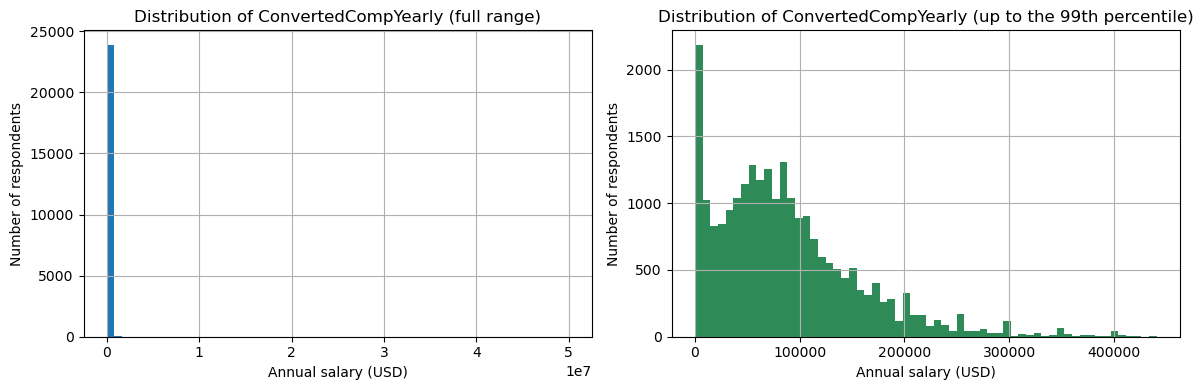

99th percentile: USD 440,856
Maximum:         USD 50,000,000


In [7]:
## Understanding distribution of target
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## Full range: a few extreme salaries stretch the axis so far that everyone else
## is squeezed into the first bar
df[col_y].hist(bins=60, ax=ax[0])
ax[0].set_title('Distribution of ConvertedCompYearly (full range)')
ax[0].set_xlabel('Annual salary (USD)')
ax[0].set_ylabel('Number of respondents')

## Same data, but the axis is limited to the 99th percentile so the shape is visible
limit = df[col_y].quantile(0.99)
df[df[col_y] <= limit][col_y].hist(bins=60, ax=ax[1], color='seagreen')
ax[1].set_title('Distribution of ConvertedCompYearly (up to the 99th percentile)')
ax[1].set_xlabel('Annual salary (USD)')
ax[1].set_ylabel('Number of respondents')

plt.tight_layout()
plt.show()

print(f'99th percentile: USD {limit:,.0f}')
print(f'Maximum:         USD {df[col_y].max():,.0f}')

The full histogram is difficult to read because a few very large values stretch the x-axis.
Limiting the second plot to the 99th percentile makes the main salary distribution clearer.

MAE will be used as the main metric because RMSE gives much more weight to large errors.


### 2.3.1.2 Understanding distribution of features

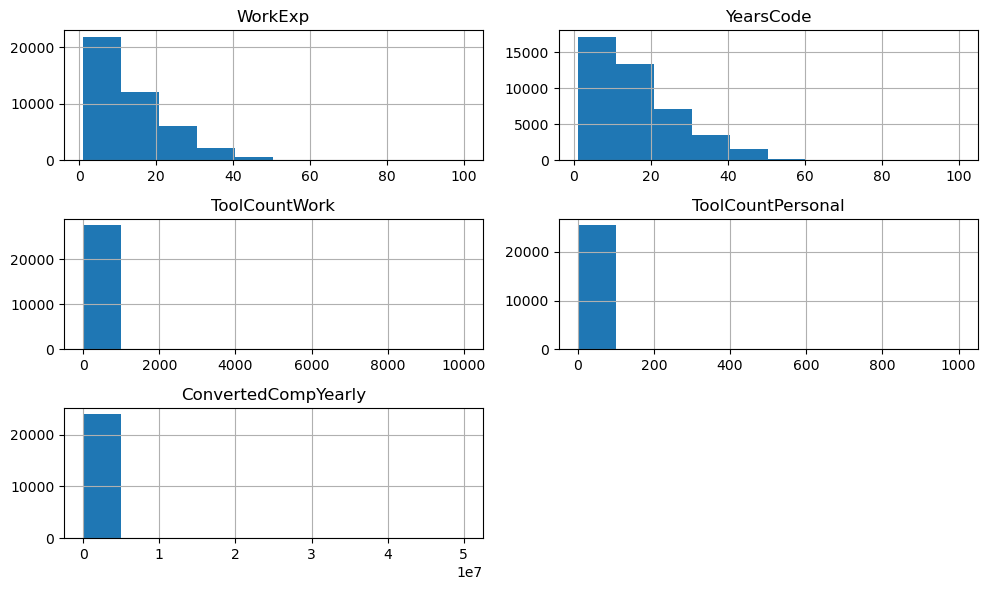

In [8]:
## Convert numeric-looking columns for plotting
df_numeric = df.copy()

for col in ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']:
    df_numeric[col] = df_numeric[col].replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_numeric.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


In [9]:
## Check the categorical columns
col_categorical = df.select_dtypes(include=['object']).columns

for col in col_categorical:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()[:8]}')
    print()


Employment (6): ['Employed' 'Independent contractor, freelancer, or self-employed'
 'Student' 'Retired' 'Not employed' 'I prefer not to say' nan]

MainBranch (6): ['I am a developer by profession'
 'I am not primarily a developer, but I write code sometimes as part of my work/studies'
 'I used to be a developer by profession, but no longer am'
 'I code primarily as a hobby'
 'I work with developers or my work supports developers but am not a developer by profession'
 'I am learning to code']

Country (177): ['Ukraine' 'Netherlands' 'India' 'Georgia' 'Australia' 'Greece' 'Germany'
 'Bangladesh']

Age (7): ['25-34 years old' '35-44 years old' '45-54 years old' '18-24 years old'
 '65 years or older' '55-64 years old' 'Prefer not to say']

EdLevel (8): ['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)'
 'Associate degree (A.A., A.S., etc.)'
 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'
 'Some college/university study without earning a degree'
 'Professional degree (JD, MD, Ph.D, Ed.D, et

`Country`, `Industry` and `DevType` contain many categories. Rare categories will be grouped later
so that one-hot encoding does not create too many columns with very little data.


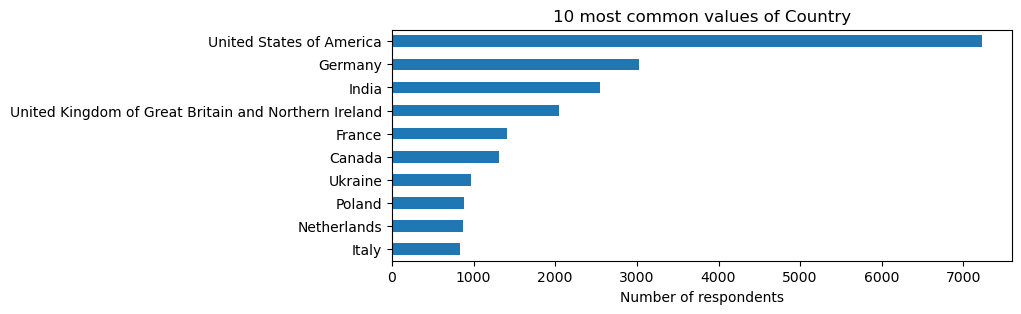

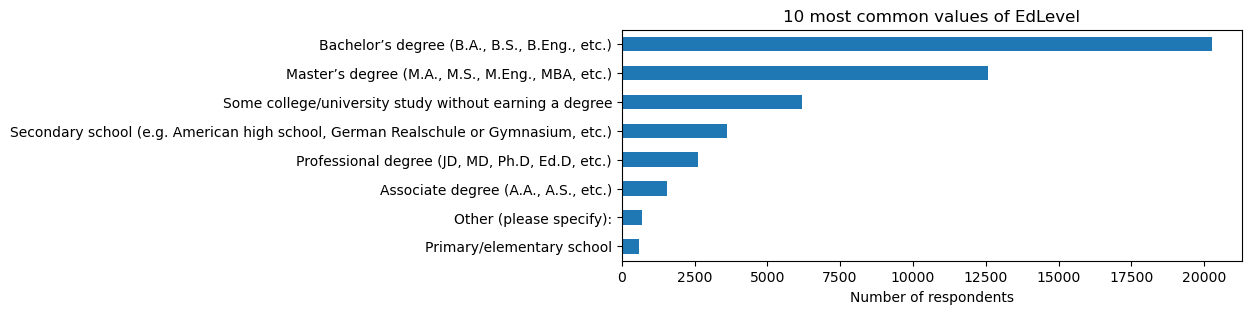

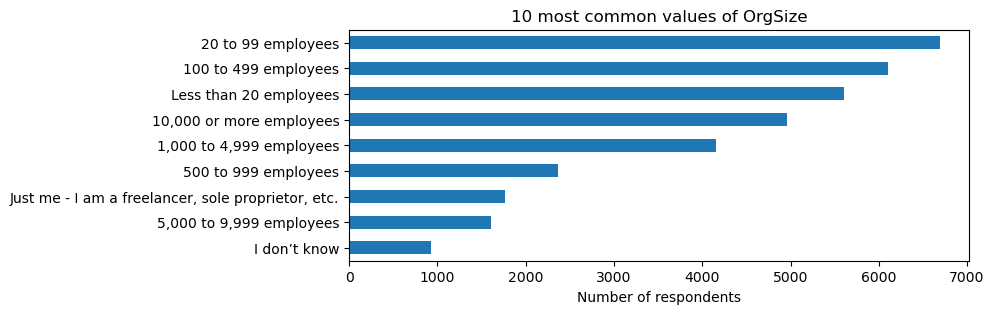

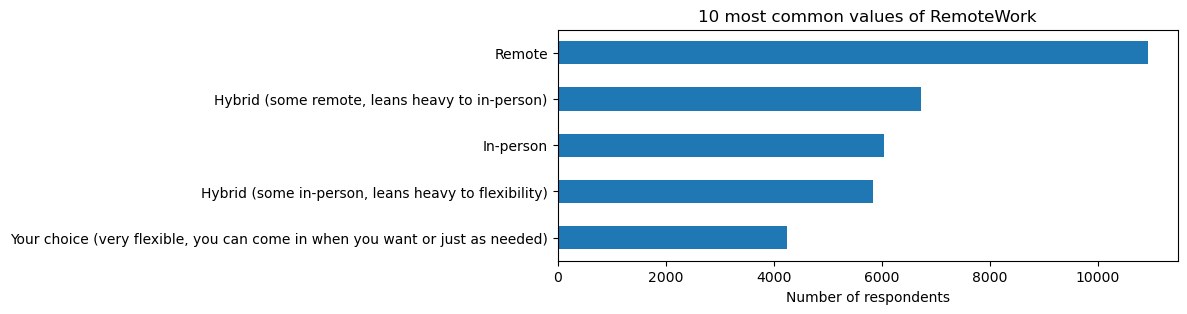

In [10]:
## Understanding distribution of the most common categories
for col in ['Country', 'EdLevel', 'OrgSize', 'RemoteWork']:
    df[col].value_counts().head(10).plot(kind='barh', figsize=(8, 3))
    plt.title(f'10 most common values of {col}')
    plt.xlabel('Number of respondents')
    plt.ylabel('')
    plt.gca().invert_yaxis()
    plt.show()

Most responses come from a small number of countries. The model should therefore be more reliable
for countries with more survey responses.


### 2.3.2 Understanding relationship between variables

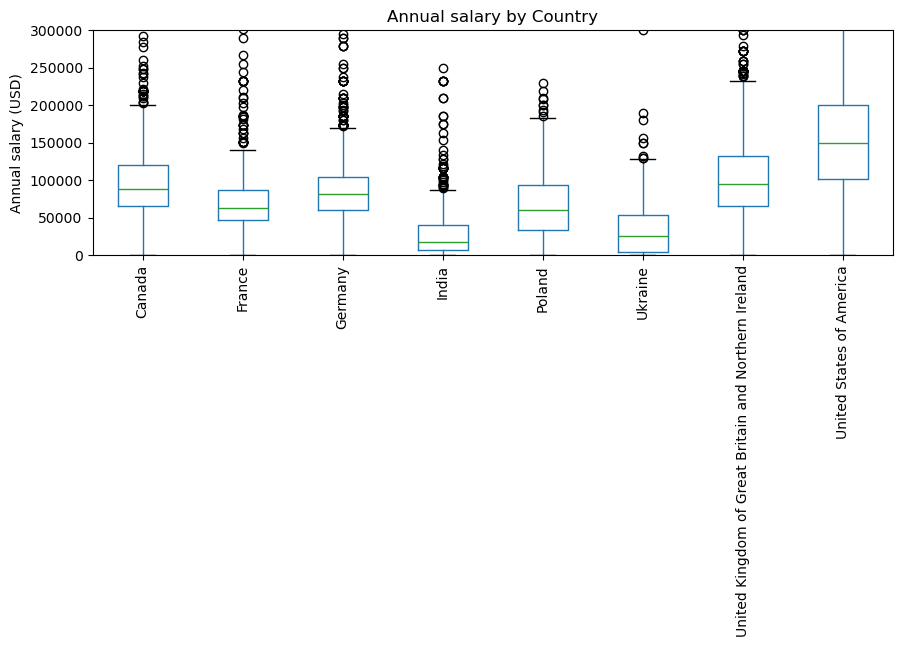

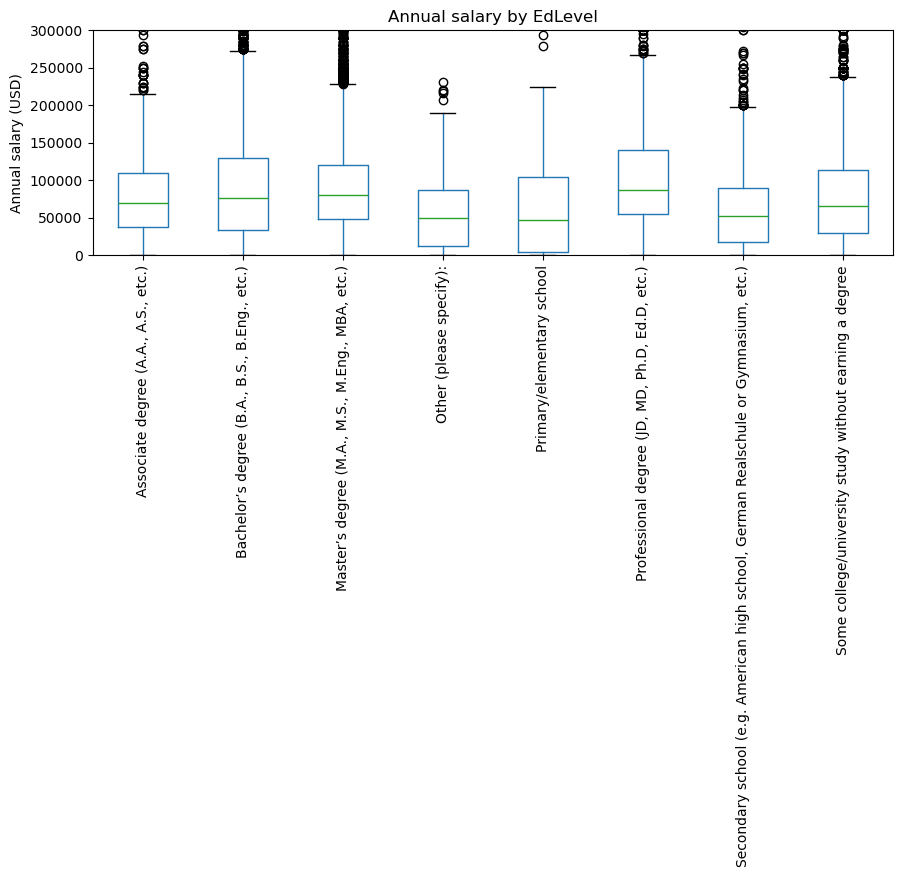

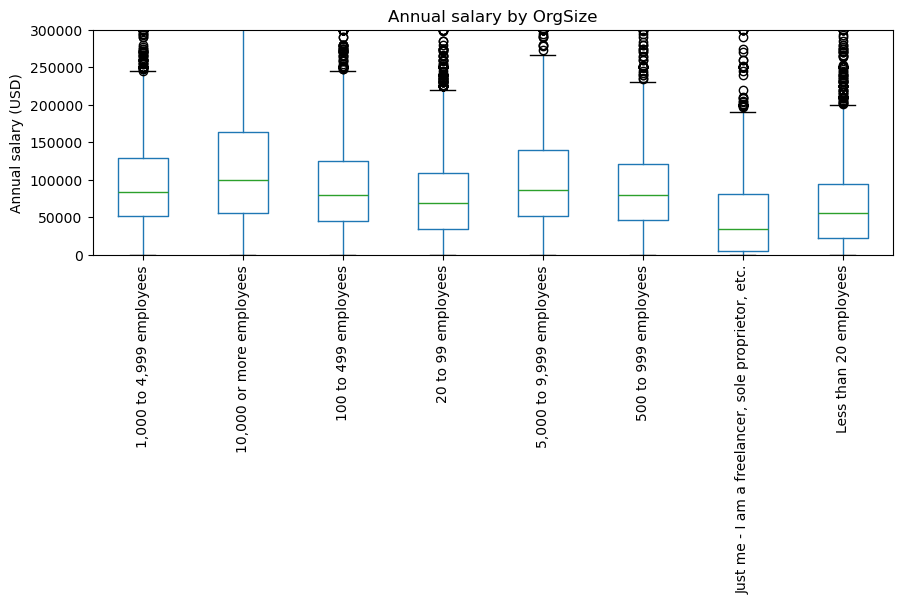

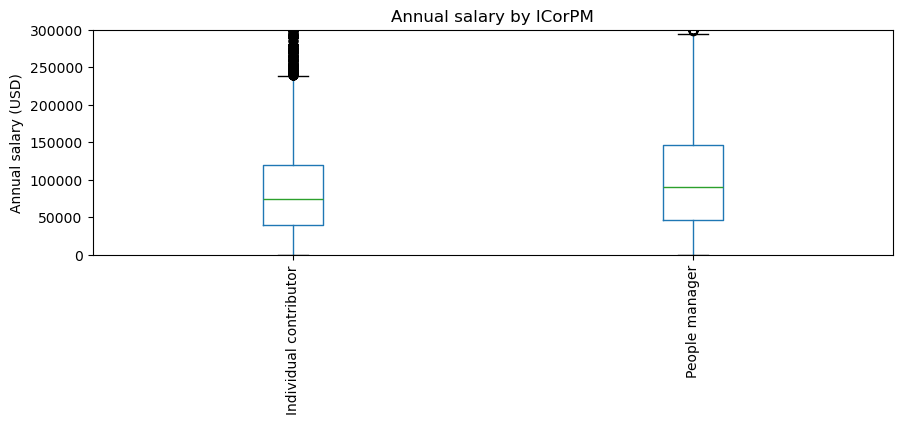

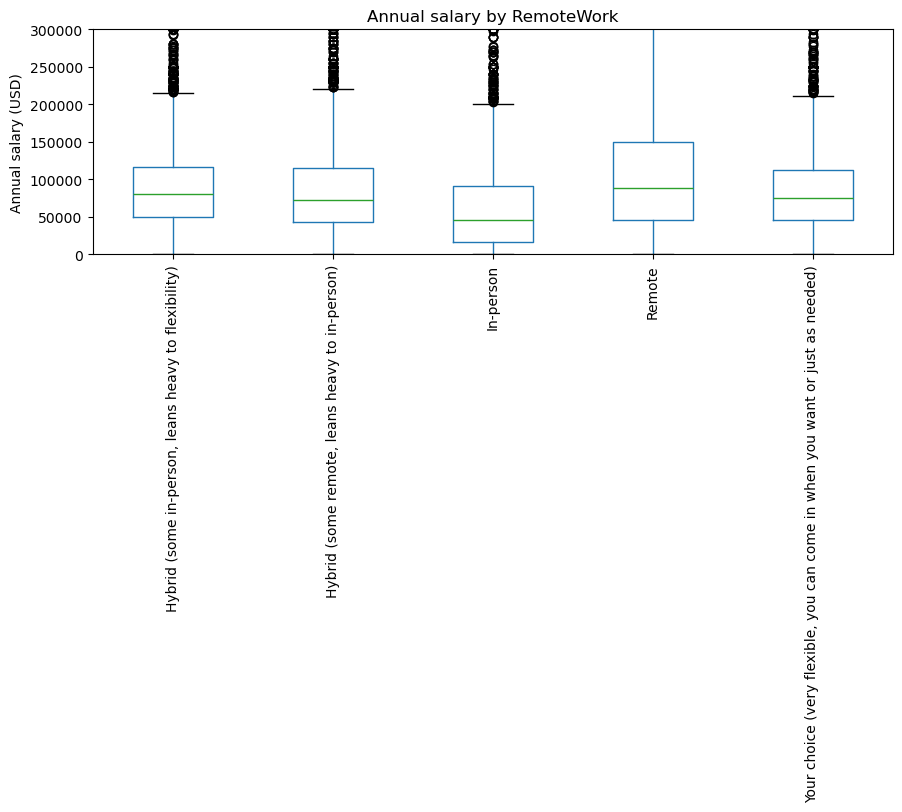

In [11]:
## Understanding relationship between variables
## Salary against each categorical feature, limited to the 8 most common values so the plot stays readable
for col in ['Country', 'EdLevel', 'OrgSize', 'ICorPM', 'RemoteWork']:
    top_values = df[col].value_counts().head(8).index

    df[df[col].isin(top_values)].boxplot(column=col_y, by=col, grid=False, rot=90, figsize=(10, 3))
    plt.title(f'Annual salary by {col}')
    plt.suptitle('')
    plt.xlabel('')
    plt.ylabel('Annual salary (USD)')
    plt.ylim(0, 300000)
    plt.show()

Country shows the clearest difference in salary. Organisation size and whether the respondent is
an individual contributor or manager also appear useful, so these features will be kept.


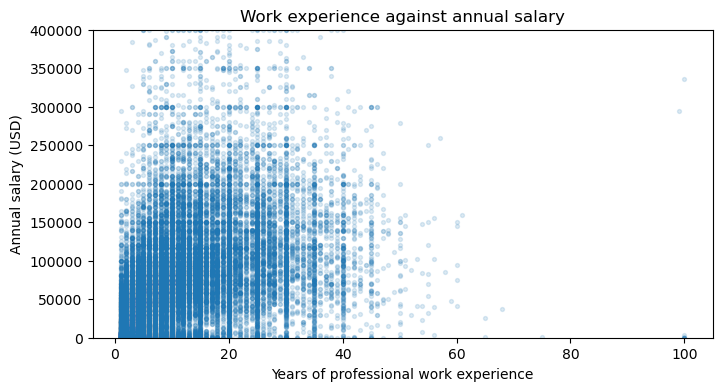

In [12]:
## Relationship between work experience and salary
plt.figure(figsize=(8, 4))
plt.scatter(df_numeric['WorkExp'], df_numeric[col_y], alpha=0.15, s=8)
plt.title('Work experience against annual salary')
plt.xlabel('Years of professional work experience')
plt.ylabel('Annual salary (USD)')
plt.ylim(0, 400000)
plt.show()

Salary generally increases with work experience, but there is still a wide spread at each
experience level. Other features are needed together with experience.


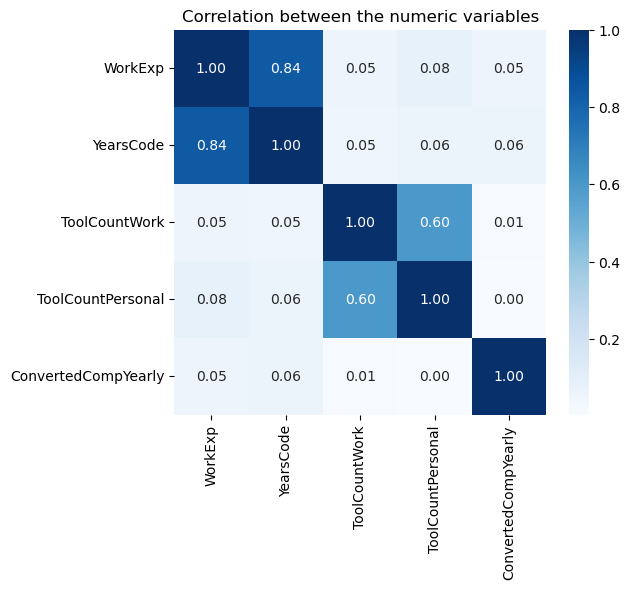

In [13]:
## Correlation between the numeric variables
plt.figure(figsize=(6, 5))
sns.heatmap(df_numeric.select_dtypes(include=['float64', 'int64']).corr(),
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation between the numeric variables')
plt.show()

`WorkExp` and `YearsCode` have a strong correlation because they both measure experience.
Their individual correlations with salary are much lower, so the categorical features may also
contain important information.


# 3. Data Preparation

## 3.1 Data Cleaning

In [14]:
## Keep employed respondents with a known salary
print('Records before cleaning:', len(df))

df = df[df['Employment'] == 'Employed'].copy()
print('After keeping employed respondents only:', len(df))

df[col_y] = pd.to_numeric(df[col_y], errors='coerce')
df = df[df[col_y].notna()].copy()
print('After dropping rows with no salary:', len(df))


Records before cleaning: 49191
After keeping employed respondents only: 33750
After dropping rows with no salary: 19500


### Checking the largest salary values

A few very large salaries may have a strong effect on models that use squared error. The table
below checks how much of the total squared deviation comes from the largest records.


In [15]:
## Check the influence of the largest salaries
deviation_squared = (df[col_y] - df[col_y].median()) ** 2
largest_records = [1, 3, 10, 20, 100]

error_percentage = []
for number in largest_records:
    largest_error = deviation_squared.nlargest(number).sum()
    error_percentage.append(largest_error / deviation_squared.sum() * 100)

influence = pd.DataFrame({
    'Largest records': largest_records,
    'Percentage of all records': np.array(largest_records) / len(df) * 100,
    'Percentage of total squared error': error_percentage
})

influence.round(2)


,Largest records,Percentage of all records,Percentage of total squared error
0,1,0.01,48.31
1,3,0.02,72.92
2,10,0.05,92.16
3,20,0.10,93.21
4,100,0.51,95.17


In [16]:
## The largest salaries, with the country they were reported from
df.nlargest(8, col_y)[['Country', col_y]]

,Country,ConvertedCompYearly
28700,Ukraine,33552715.0
43143,Poland,18387548.0
35353,"Iran, Islamic Republic of...",15430267.0
45971,Netherlands,13921760.0
24900,India,9531653.0
10025,United States of America,9000000.0
30728,Brazil,6371285.0
40418,Viet Nam,6000000.0


The largest salary records make up a very small part of the dataset but a large part of
the squared deviation. Several may be reporting or currency-conversion problems.

Instead of using an IQR rule, the model uses a clear fixed scope. An IQR rule would remove many
valid high salaries because the survey combines countries with very different pay levels.

Version 5.2 covers annual salaries from **USD 10,000 to USD 500,000**. The upper limit keeps almost
all employed salary responses while removing the most extreme tail. USD 250k–500k remains in scope
because those salaries can be legitimate, but that section is evaluated separately because it has
fewer records.

In [17]:
## Keep salaries inside the range covered by this model
SALARY_FLOOR = 10000
SALARY_CEILING = 500000

print('Salaries below the floor:  ', (df[col_y] < SALARY_FLOOR).sum())
print('Salaries above the ceiling:', (df[col_y] > SALARY_CEILING).sum())

salary_in_range = (
    (df[col_y] >= SALARY_FLOOR) &
    (df[col_y] <= SALARY_CEILING)
)

df = df[salary_in_range].copy()
print(f'After keeping salaries between USD {SALARY_FLOOR:,} and USD {SALARY_CEILING:,}:', len(df))


Salaries below the floor:   1681
Salaries above the ceiling: 140
After keeping salaries between USD 10,000 and USD 500,000: 17679


In [18]:
## Convert experience and tool-count columns to numbers
col_numeric = ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']

for col in col_numeric:
    df[col] = df[col].replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Keep experience inside the range covered by this model
EXPERIENCE_MAX = 50

print('YearsCode above the limit:', (df['YearsCode'] > EXPERIENCE_MAX).sum())
print('WorkExp above the limit:  ', (df['WorkExp'] > EXPERIENCE_MAX).sum())

over_experience_limit = (
    (df['YearsCode'] > EXPERIENCE_MAX) |
    (df['WorkExp'] > EXPERIENCE_MAX)
)

df = df[~over_experience_limit].copy()
print(f'After keeping experience within {EXPERIENCE_MAX} years:', len(df))

df.info()


YearsCode above the limit: 28
WorkExp above the limit:   8
After keeping experience within 50 years: 17650
<class 'pandas.core.frame.DataFrame'>
Index: 17650 entries, 0 to 49122
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employment              17650 non-null  object 
 1   MainBranch              17650 non-null  object 
 2   Country                 17650 non-null  object 
 3   Age                     17650 non-null  object 
 4   EdLevel                 17637 non-null  object 
 5   DevType                 17650 non-null  object 
 6   OrgSize                 17638 non-null  object 
 7   ICorPM                  17406 non-null  object 
 8   RemoteWork              17566 non-null  object 
 9   Industry                17626 non-null  object 
 10  PurchaseInfluence       17623 non-null  object 
 11  NewRole                 17621 non-null  object 
 12  WorkExp                 17509 non-null  fl

In [19]:
## Check missing values after row-level cleaning
## Imputation is performed after the split using training-set values only.
df.isna().sum().sort_values(ascending=False)

WebframeHaveWorkedWith    5354
ToolCountPersonal         4294
PlatformHaveWorkedWith    4026
DatabaseHaveWorkedWith    3841
ToolCountWork             2529
LanguageHaveWorkedWith    1093
ICorPM                     244
WorkExp                    141
RemoteWork                  84
YearsCode                   55
NewRole                     29
PurchaseInfluence           27
Industry                    24
EdLevel                     13
OrgSize                     12
MainBranch                   0
Employment                   0
Age                          0
Country                      0
DevType                      0
ConvertedCompYearly          0
dtype: int64

Missing numeric values are filled with the median, while missing categorical values are labelled
as `'Unknown'`. This keeps rows that still contain useful information.

The salary and experience limits are fixed model boundaries rather than a general outlier rule.
Unusual values inside those boundaries are kept.


## 3.2 Feature Engineering

The existing model features are retained and the following features are added:

1. `PrimaryDevType` keeps the first developer role.
2. `ToolCountTotal` adds the work and personal tool counts.
3. `CodingBeforeWork` estimates years spent coding before professional work.
4. `LanguageCount`, `DatabaseCount`, `PlatformCount` and `WebFrameworkCount` summarise technology
   exposure without one-hot encoding thousands of full response combinations.
5. Selected yes/no technology flags retain information about common languages, databases,
   platforms and frameworks.
6. `MainBranch` distinguishes professional developers from other respondent types.

The wider category limits retain more salary information than the earlier grouping while still
placing uncommon categories into `Other`.

In [20]:
## Basic feature engineering
df['PrimaryDevType'] = df['DevType'].str.split(';').str[0].str.strip()
df['ToolCountTotal'] = df['ToolCountWork'] + df['ToolCountPersonal']
df['CodingBeforeWork'] = (df['YearsCode'] - df['WorkExp']).clip(lower=0)

## Count selected items in the four technology questions
tech_count_sources = {
    'LanguageCount': 'LanguageHaveWorkedWith',
    'DatabaseCount': 'DatabaseHaveWorkedWith',
    'PlatformCount': 'PlatformHaveWorkedWith',
    'WebFrameworkCount': 'WebframeHaveWorkedWith'
}

def count_items(value):
    if pd.isna(value) or value == '':
        return 0
    return len(str(value).split(';'))

for feature, source_column in tech_count_sources.items():
    df[feature] = df[source_column].apply(count_items)

## Keep simple yes/no flags for common technologies
tech_flags = {
    'UsesPython': ('LanguageHaveWorkedWith', 'Python'),
    'UsesJavaScript': ('LanguageHaveWorkedWith', 'JavaScript'),
    'UsesTypeScript': ('LanguageHaveWorkedWith', 'TypeScript'),
    'UsesJava': ('LanguageHaveWorkedWith', 'Java'),
    'UsesCSharp': ('LanguageHaveWorkedWith', 'C#'),
    'UsesSQL': ('LanguageHaveWorkedWith', 'SQL'),
    'UsesGo': ('LanguageHaveWorkedWith', 'Go'),
    'UsesRust': ('LanguageHaveWorkedWith', 'Rust'),
    'UsesPostgreSQL': ('DatabaseHaveWorkedWith', 'PostgreSQL'),
    'UsesMySQL': ('DatabaseHaveWorkedWith', 'MySQL'),
    'UsesSQLServer': ('DatabaseHaveWorkedWith', 'Microsoft SQL Server'),
    'UsesMongoDB': ('DatabaseHaveWorkedWith', 'MongoDB'),
    'UsesRedis': ('DatabaseHaveWorkedWith', 'Redis'),
    'UsesAWS': ('PlatformHaveWorkedWith', 'Amazon Web Services (AWS)'),
    'UsesAzure': ('PlatformHaveWorkedWith', 'Microsoft Azure'),
    'UsesGoogleCloud': ('PlatformHaveWorkedWith', 'Google Cloud'),
    'UsesDocker': ('PlatformHaveWorkedWith', 'Docker'),
    'UsesKubernetes': ('PlatformHaveWorkedWith', 'Kubernetes'),
    'UsesReact': ('WebframeHaveWorkedWith', 'React'),
    'UsesNodeJS': ('WebframeHaveWorkedWith', 'Node.js'),
    'UsesSpringBoot': ('WebframeHaveWorkedWith', 'Spring Boot'),
    'UsesASPNETCore': ('WebframeHaveWorkedWith', 'ASP.NET Core'),
    'UsesFastAPI': ('WebframeHaveWorkedWith', 'FastAPI'),
    'UsesDjango': ('WebframeHaveWorkedWith', 'Django')
}

def contains_item(value, item):
    if pd.isna(value):
        return 0
    return int(item in str(value).split(';'))

for feature, (source_column, item) in tech_flags.items():
    df[feature] = df[source_column].apply(
        lambda value, selected=item: contains_item(value, selected)
    )

df[[
    'PrimaryDevType', 'ToolCountTotal', 'CodingBeforeWork',
    'LanguageCount', 'DatabaseCount', 'PlatformCount', 'WebFrameworkCount'
]].head()

,PrimaryDevType,ToolCountTotal,CodingBeforeWork,LanguageCount,DatabaseCount,PlatformCount,WebFrameworkCount
0,"Developer, mobile",10.0,6.0,3,2,5,0
1,"Developer, back-end",11.0,8.0,1,2,7,1
3,"Developer, back-end",NaN,1.0,3,0,2,1
7,"Architect, software or solutions",20.0,8.0,6,3,7,2
8,Data engineer,NaN,6.0,3,10,5,2


In [21]:
## Category limits are learned from the training data after the split
col_limit = {
    'Country': 30,
    'Industry': 20,
    'PrimaryDevType': 20
}

col_limit

{'Country': 30, 'Industry': 20, 'PrimaryDevType': 20}

In [22]:
## Select the final raw features
tech_count_features = list(tech_count_sources)
tech_flag_features = list(tech_flags)

col_x_numeric = [
    'WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal',
    'ToolCountTotal', 'CodingBeforeWork'
] + tech_count_features + tech_flag_features

col_x_categorical = [
    'Country', 'Age', 'EdLevel', 'PrimaryDevType', 'OrgSize',
    'ICorPM', 'RemoteWork', 'Industry', 'PurchaseInfluence',
    'NewRole', 'MainBranch'
]

col_x = col_x_numeric + col_x_categorical

x = df[col_x].copy()
y = df[col_y].copy()

print('Number of model inputs before one-hot encoding:', len(col_x))
x.head()

Number of model inputs before one-hot encoding: 45


,WorkExp,YearsCode,ToolCountWork,ToolCountPersonal,ToolCountTotal,CodingBeforeWork,LanguageCount,DatabaseCount,PlatformCount,WebFrameworkCount,...,Age,EdLevel,PrimaryDevType,OrgSize,ICorPM,RemoteWork,Industry,PurchaseInfluence,NewRole,MainBranch
0,8.0,14.0,7.0,3.0,10.0,6.0,3,2,5,0,...,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,"Yes, I influenced the purchase of a substantia...",I have neither consider or transitioned into a...,I am a developer by profession
1,2.0,10.0,6.0,5.0,11.0,8.0,1,2,7,1,...,25-34 years old,"Associate degree (A.A., A.S., etc.)","Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",Retail and Consumer Services,No,I have transitioned into a new career and/or i...,I am a developer by profession
3,4.0,5.0,NaN,NaN,NaN,1.0,3,0,2,1,...,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end","10,000 or more employees",Individual contributor,Remote,Retail and Consumer Services,No,I have neither consider or transitioned into a...,I am a developer by profession
7,22.0,30.0,10.0,10.0,20.0,8.0,6,3,7,2,...,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Architect, software or solutions",Less than 20 employees,People manager,Remote,Software Development,"Yes, I influenced the purchase of a substantia...",I have strongly considered changing my career ...,I am a developer by profession
8,9.0,15.0,NaN,NaN,NaN,6.0,3,10,5,2,...,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data engineer,"5,000 to 9,999 employees",Individual contributor,Remote,Banking/Financial Services,"Yes, I influenced the purchase of a tool that ...",I have transitioned into a new career and/or i...,I am a developer by profession


## 3.3 Train-Test Split

In [23]:
## Split once so every model uses the same records
from sklearn.model_selection import train_test_split

test_size = 0.25
random_state = 67

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=test_size,
    random_state=random_state
)

print('Training records:', len(x_train))
print('Testing records:', len(x_test))

Training records: 13237
Testing records: 4413


### Training-only preprocessing

Missing-value replacements and common-category lists are learned from `x_train`. The same stored
values are then applied to `x_test`. This avoids letting test-set distributions influence model
preparation.

In [24]:
## Learn numeric replacement values from the training data
numeric_medians = x_train[col_x_numeric].median()
x_train[col_x_numeric] = x_train[col_x_numeric].fillna(numeric_medians)
x_test[col_x_numeric] = x_test[col_x_numeric].fillna(numeric_medians)

## Preserve missing categorical responses as a visible category
x_train[col_x_categorical] = x_train[col_x_categorical].fillna('Unknown')
x_test[col_x_categorical] = x_test[col_x_categorical].fillna('Unknown')

## Learn common categories from the training data only
category_top_values = {}

for column, limit in col_limit.items():
    top_values = x_train[column].value_counts().head(limit).index.tolist()
    category_top_values[column] = top_values

    x_train[column] = x_train[column].where(
        x_train[column].isin(top_values),
        'Other'
    )
    x_test[column] = x_test[column].where(
        x_test[column].isin(top_values),
        'Other'
    )

## Store category choices for one-hot encoding and the web app
col_options = {}

for column in col_x_categorical:
    options = sorted(x_train[column].unique().tolist())
    col_options[column] = options

    x_train[column] = pd.Categorical(
        x_train[column],
        categories=options
    )
    x_test[column] = pd.Categorical(
        x_test[column],
        categories=options
    )

## One-hot encode training data and align the test columns
x_train = pd.get_dummies(x_train, drop_first=True, dtype=int)
x_test = pd.get_dummies(x_test, drop_first=True, dtype=int)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

## Technology choices are metadata used by the matching web app
training_index = y_train.index
tech_options = {}

for source_column in tech_count_sources.values():
    options = (
        df.loc[training_index, source_column]
        .dropna()
        .astype(str)
        .str.split(';')
        .explode()
        .str.strip()
    )
    tech_options[source_column] = sorted(
        options[options != ''].unique().tolist()
    )

print('Features after one-hot encoding:', x_train.shape[1])
print('Train and test columns match:', x_train.columns.equals(x_test.columns))

Features after one-hot encoding: 144
Train and test columns match: True


# 4. Modelling

Four regression models are trained and tested on the same data:

| Model | Reason for using it |
|---|---|
| Linear Regression | Simple baseline model |
| Decision Tree Regressor | Can learn non-linear patterns |
| Random Forest Regressor | Averages many decision trees |
| Gradient Boosting Regressor | Builds trees that correct earlier errors |


## 4.1 Linear Regression

In [25]:
## Initialise and train model
from sklearn.linear_model import LinearRegression

linr = LinearRegression()
linr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

## A straight line can predict below zero, which is impossible for a salary,
## so any negative prediction is floored at 0
y_pred_linr = np.maximum(linr.predict(x_test), 0)

print('Linear Regression')
print(f'MAE: {mean_absolute_error(y_test, y_pred_linr)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_linr)}')
print(f'R2: {r2_score(y_test, y_pred_linr)}')

Linear Regression
MAE: 30300.592192544515
RMSE: 46988.375355412325
R2: 0.5476645628348251


## 4.2 Decision Tree Regressor

In [27]:
## Initialise and train model
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=random_state)
tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",67
,"max_l

In [28]:
## Evaluate model
y_pred_tree = tree.predict(x_test)

print('Decision Tree Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_tree)}')
print(f'R2: {r2_score(y_test, y_pred_tree)}')

Decision Tree Regressor
MAE: 43726.953093133925
RMSE: 66943.14909772565
R2: 0.0818956802468348


## 4.3 Random Forest Regressor

In [29]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor

rtree = RandomForestRegressor(random_state=random_state, n_jobs=-1)
rtree.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
## Evaluate model
y_pred_rtree = rtree.predict(x_test)

print('Random Forest Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_rtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_rtree)}')
print(f'R2: {r2_score(y_test, y_pred_rtree)}')

Random Forest Regressor
MAE: 30540.054656696124
RMSE: 47711.59680655478
R2: 0.5336331660940967


## 4.4 Gradient Boosting Regressor

In [31]:
## Initialise and train model
from sklearn.ensemble import GradientBoostingRegressor

gtree = GradientBoostingRegressor(random_state=random_state)
gtree.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [32]:
## Evaluate model
y_pred_gtree = gtree.predict(x_test)

print('Gradient Boosting Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_gtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_gtree)}')
print(f'R2: {r2_score(y_test, y_pred_gtree)}')

Gradient Boosting Regressor
MAE: 30599.49692729008
RMSE: 47841.7031275129
R2: 0.5310861960294648


## 4.5 Model Comparison

In [33]:
## Compare the models on the same test set
model_predictions = {
    'Linear Regression': y_pred_linr,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rtree,
    'Gradient Boosting': y_pred_gtree
}

comparison_rows = []

for name in model_predictions:
    y_pred = model_predictions[name]
    comparison_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    })

comparison = pd.DataFrame(comparison_rows)

## Compare each MAE with Linear Regression
mae_linr = comparison.loc[
    comparison['Model'] == 'Linear Regression', 'MAE'
].values[0]

comparison['MAE vs Linear Regression'] = comparison['MAE'] - mae_linr
comparison['Percentage change in MAE'] = (
    (comparison['MAE'] / mae_linr - 1) * 100
)

comparison = comparison.sort_values('MAE').reset_index(drop=True)
comparison.round(2)


,Model,MAE,RMSE,R2,MAE vs Linear Regression,Percentage change in MAE
0,Linear Regression,30300.59,46988.38,0.55,0.00,0.00
1,Random Forest,30540.05,47711.60,0.53,239.46,0.79
2,Gradient Boosting,30599.50,47841.70,0.53,298.90,0.99
3,Decision Tree,43726.95,66943.15,0.08,13426.36,44.31


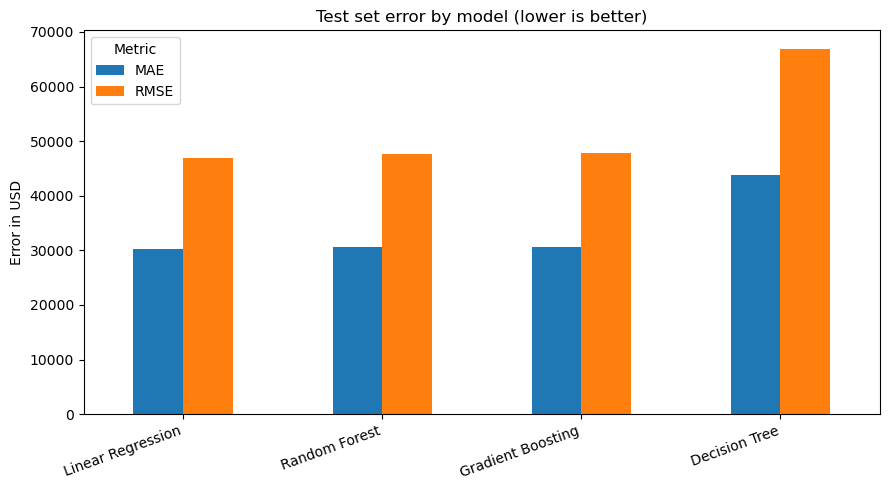

In [34]:
## Visualise the comparison
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(9, 5))
plt.title('Test set error by model (lower is better)')
plt.xlabel('')
plt.ylabel('Error in USD')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The baseline table provides an initial comparison on the common split. Gradient Boosting
and Random Forest are both taken forward because the labs cover tuning and comparing ensemble
models. Final model selection below uses training cross-validation MAE; the test results are
reported as generalisation evidence rather than used to keep changing the model.

## 4.6 Hyperparameter Tuning

`RandomizedSearchCV` tests a limited sample of parameter combinations using three-fold
cross-validation. Gradient Boosting tests 20 combinations and Random Forest tests 10.

The first two searches use MAE because it is the main metric for this project. The same models are
then tuned using MSE as a secondary experiment to give more weight to large prediction errors.

In [35]:
## Tune Gradient Boosting using training folds
param_dist_gb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 10, 20],
    'loss': ['squared_error', 'absolute_error']
}

from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingRegressor(random_state=random_state)

rs_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=2
)

rs_gb.fit(x_train, y_train)

best_params_gb = rs_gb.best_params_
best_gtree = rs_gb.best_estimator_

print('Best Gradient Boosting parameters:')
print(best_params_gb)
print(f'Best cross-validation MAE: USD {-rs_gb.best_score_:,.2f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Gradient Boosting parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 4, 'loss': 'absolute_error', 'learning_rate': 0.1}
Best cross-validation MAE: USD 28,331.92


In [36]:
## Show the combinations tested
cv_columns = [
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_min_samples_split',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

cv_results = pd.DataFrame(rs_gb.cv_results_)[cv_columns]

## Scikit-learn stores the MAE as a negative score
cv_results['mean_test_score'] = -cv_results['mean_test_score']
cv_results = cv_results.rename(columns={
    'mean_test_score': 'CV MAE (USD)',
    'std_test_score': 'Standard deviation',
    'rank_test_score': 'Rank'
})

cv_results.sort_values('Rank').round(4)


,param_n_estimators,param_learning_rate,param_max_depth,param_min_samples_split,CV MAE (USD),Standard deviation,Rank
9,300,0.10,4,10,28331.9223,508.3628,1
7,400,0.10,3,20,28506.1269,519.0508,2
5,400,0.05,4,10,28664.1783,416.2849,3
16,300,0.10,3,10,28677.2550,498.6906,4
8,400,0.03,5,10,28906.8743,493.4987,5
11,200,0.05,5,20,29111.1057,466.7810,6
15,400,0.05,3,20,29180.8339,478.0765,7
0,400,0.05,5,10,29274.2335,364.8053,8
12,200,0.10,4,10,29308.4089,295.2698,9
17,400,0.03,4,10,29347.4147,504.4370,10


In [37]:
## Tune Random Forest using the same training-fold metric
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': ['sqrt', 0.5, 1.0],
    'max_samples': [None, 0.7, 0.9]
}

rf = RandomForestRegressor(
    random_state=random_state,
    n_jobs=-1
)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=2
)

rs_rf.fit(x_train, y_train)

best_params_rf = rs_rf.best_params_
best_rtree = rs_rf.best_estimator_

print('Best Random Forest parameters:')
print(best_params_rf)
print(f'Best cross-validation MAE: USD {-rs_rf.best_score_:,.2f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'max_samples': None, 'max_features': 0.5, 'max_depth': 30}
Best cross-validation MAE: USD 30,856.81


### MSE tuning experiment

The following searches use MSE instead of MAE. These models are retained for the salary-range
comparison, but the final saved model is still selected using cross-validation MAE.

In [38]:
## Tune Gradient Boosting using MSE instead of MAE
gb_mse = GradientBoostingRegressor(
    random_state=random_state
)

rs_gb_mse = RandomizedSearchCV(
    estimator=gb_mse,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=2
)

rs_gb_mse.fit(x_train, y_train)

best_gtree_mse = rs_gb_mse.best_estimator_

cv_mse = -rs_gb_mse.best_score_
cv_rmse = np.sqrt(cv_mse)

print('Best MSE-tuned parameters:')
print(rs_gb_mse.best_params_)
print(f'Best CV MSE:  {cv_mse:,.2f}')
print(f'Best CV RMSE: USD {cv_rmse:,.2f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best MSE-tuned parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 4, 'loss': 'squared_error', 'learning_rate': 0.1}
Best CV MSE:  2,027,614,839.57
Best CV RMSE: USD 45,029.04


In [39]:
## Tune Random Forest using MSE
rf_mse = RandomForestRegressor(
    random_state=random_state,
    n_jobs=-1
)

rs_rf_mse = RandomizedSearchCV(
    estimator=rf_mse,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=2
)

rs_rf_mse.fit(x_train, y_train)

best_rtree_mse = rs_rf_mse.best_estimator_

rf_cv_mse = -rs_rf_mse.best_score_
rf_cv_rmse = np.sqrt(rf_cv_mse)

print('Best MSE-tuned Random Forest parameters:')
print(rs_rf_mse.best_params_)
print(f'Best CV RMSE: USD {rf_cv_rmse:,.2f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best MSE-tuned Random Forest parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'max_samples': None, 'max_features': 0.5, 'max_depth': 30}
Best CV RMSE: USD 46,775.75


In [40]:
## Compare tuning objectives across salary ranges
salary_bins = [
    SALARY_FLOOR,
    25_000,
    50_000,
    75_000,
    100_000,
    150_000,
    250_000,
    300_000,
    400_000,
    SALARY_CEILING + 1
]

salary_labels = [
    '10k to 25k',
    '25k to 50k',
    '50k to 75k',
    '75k to 100k',
    '100k to 150k',
    '150k to 250k',
    '250k to 300k',
    '300k to 400k',
    '400k to 500k'
]

salary_bands = pd.cut(
    y_test.to_numpy(),
    bins=salary_bins,
    labels=salary_labels,
    right=False
)

models_by_objective = {
    'GBT tuned for MAE': best_gtree,
    'GBT tuned for MSE': best_gtree_mse,
    'RF tuned for MAE': best_rtree,
    'RF tuned for MSE': best_rtree_mse
}

range_error_data = pd.DataFrame({
    'Salary range': salary_bands
})

for name, model in models_by_objective.items():
    prediction = model.predict(x_test)

    range_error_data[name] = np.abs(
        y_test.to_numpy() - prediction
    )

range_mae_comparison = range_error_data.groupby(
    'Salary range',
    observed=False
)[list(models_by_objective)].mean()

range_counts = range_error_data.groupby(
    'Salary range',
    observed=False
).size()

range_summary = range_mae_comparison.copy()
range_summary.insert(0, 'Test records', range_counts)

range_summary.round(2)

,Test records,GBT tuned for MAE,GBT tuned for MSE,RF tuned for MAE,RF tuned for MSE
Salary range,,,,,
10k to 25k,323,20062.80,24956.64,29876.43,29876.43
25k to 50k,691,16722.07,21244.14,23830.60,23830.60
50k to 75k,914,16006.80,19084.12,20042.08,20042.08
75k to 100k,818,16572.23,18966.96,19211.24,19211.24
100k to 150k,852,25852.57,27651.00,28897.33,28897.33
150k to 250k,624,40538.44,37325.55,38963.88,38963.88
250k to 300k,88,104991.56,85197.55,85732.83,85732.83
300k to 400k,76,172942.10,148120.72,149864.88,149864.88
400k to 500k,27,278615.21,251576.75,245896.72,245896.72


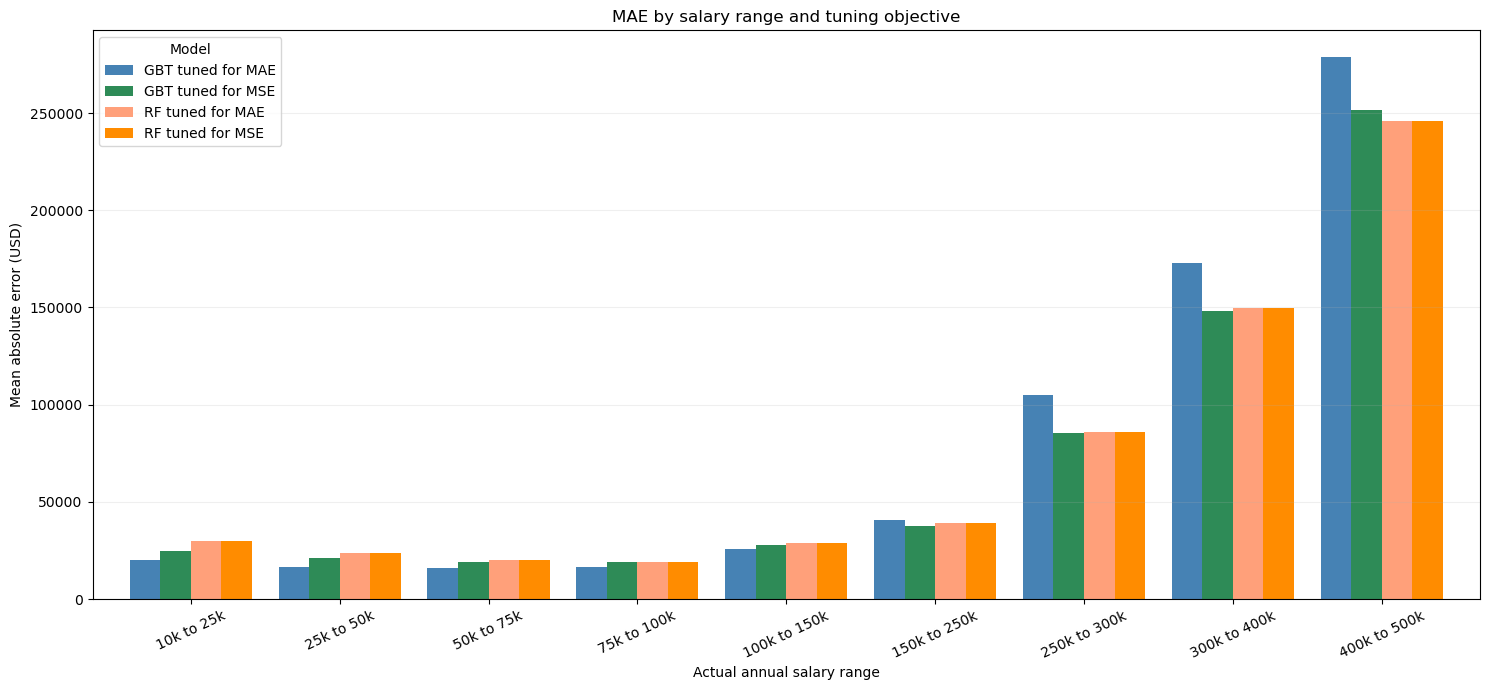

In [41]:
ax = range_mae_comparison.plot(
    kind='bar',
    figsize=(15, 7),
    width=0.82,
    color=['steelblue', 'seagreen', 'lightsalmon', 'darkorange']
)

ax.set_title('MAE by salary range and tuning objective')
ax.set_xlabel('Actual annual salary range')
ax.set_ylabel('Mean absolute error (USD)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### Final model selection

The MSE-tuned models are a secondary experiment for investigating large errors. MAE remains the
main metric, so the final saved model is selected between the MAE-tuned Gradient Boosting and
Random Forest models using the lowest training cross-validation MAE.

The test set is not used for this selection.

In [42]:
## Select the final model using training cross-validation MAE
mae_models = {
    'GBT tuned for MAE': best_gtree,
    'RF tuned for MAE': best_rtree
}

mae_cv_results = pd.DataFrame({
    'Model': [
        'GBT tuned for MAE',
        'RF tuned for MAE'
    ],
    'CV MAE': [
        -rs_gb.best_score_,
        -rs_rf.best_score_
    ]
})

mae_cv_results = mae_cv_results.sort_values(
    'CV MAE'
).reset_index(drop=True)

best_model_name = mae_cv_results.loc[0, 'Model']
best_model = mae_models[best_model_name]

print('Final model:', best_model_name)
mae_cv_results.round(2)

Final model: GBT tuned for MAE


,Model,CV MAE
0,GBT tuned for MAE,28331.92
1,RF tuned for MAE,30856.81


# 5. Model Evaluation

## 5.1 Choice of evaluation metric

- **MAE** is the main metric because it gives the average error in dollars.
- **RMSE** gives more weight to very large errors.
- **R2** shows how much of the variation in salary is explained by the model.

Salary also depends on information that is not in the survey, so the prediction should be treated
as an estimate rather than an exact figure.


In [43]:
## Evaluate the model selected from training cross-validation
y_pred_final = best_model.predict(x_test)

final_test_mae = mean_absolute_error(y_test, y_pred_final)
final_test_rmse = root_mean_squared_error(y_test, y_pred_final)
final_test_r2 = r2_score(y_test, y_pred_final)

print('Final model:', best_model_name)
print(f'MAE: USD {final_test_mae:,.2f}')
print(f'RMSE: USD {final_test_rmse:,.2f}')
print(f'R²: {final_test_r2:.4f}')

Final model: GBT tuned for MAE
MAE: USD 27,974.03
RMSE: USD 47,678.13
R²: 0.5343


## 5.2 Actual against predicted salary

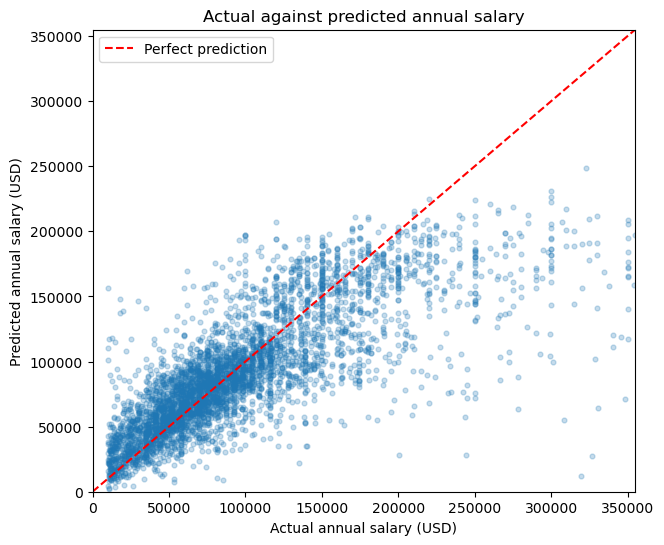

In [44]:
## Compare the actual and predicted salaries of the final model
scatter_limit = float(y_test.quantile(0.99))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_final, alpha=0.25, s=12)
plt.plot([0, scatter_limit], [0, scatter_limit], color='red', linestyle='--', label='Perfect prediction')
plt.xlim(0, scatter_limit)
plt.ylim(0, scatter_limit)
plt.title('Actual against predicted annual salary')
plt.xlabel('Actual annual salary (USD)')
plt.ylabel('Predicted annual salary (USD)')
plt.legend()
plt.show()

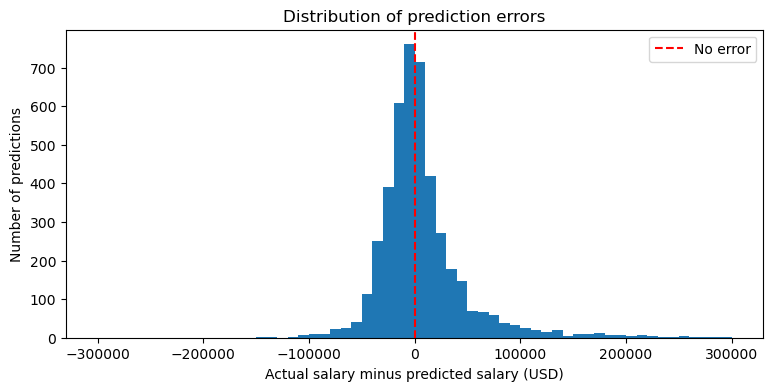

Average error: 7,889.93 USD
Median error:  -418.27 USD
Share of predictions that are too low: 49.26%


In [45]:
## Distribution of the prediction errors
residuals = y_test.to_numpy() - y_pred_final

plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=60, range=(-300000, 300000))
plt.axvline(x=0, color='red', linestyle='--', label='No error')
plt.title('Distribution of prediction errors')
plt.xlabel('Actual salary minus predicted salary (USD)')
plt.ylabel('Number of predictions')
plt.legend()
plt.show()

print(f'Average error: {residuals.mean():,.2f} USD')
print(f'Median error:  {np.median(residuals):,.2f} USD')
print(f'Share of predictions that are too low: {(residuals > 0).mean() * 100:.2f}%')

Points closer to the red line have better predictions. The model follows the middle salary range
more closely but tends to under-predict the highest salaries.

The result should be used as a rough benchmark, especially for senior or highly paid users.


## 5.3 Where the model works and where it does not

In [46]:
## Check error across narrower salary ranges
salary_range = pd.cut(
    y_test,
    bins=[
        SALARY_FLOOR, 25000, 50000, 75000, 100000,
        150000, 250000, 300000, 400000, SALARY_CEILING + 1
    ],
    labels=[
        '10k to 25k', '25k to 50k', '50k to 75k',
        '75k to 100k', '100k to 150k', '150k to 250k',
        '250k to 300k', '300k to 400k', '400k to 500k'
    ],
    right=False
)

error_table = pd.DataFrame({
    'Salary range': salary_range,
    'Absolute error': np.abs(residuals),
    'Actual salary': y_test.to_numpy()
})

error_by_range = error_table.groupby(
    'Salary range',
    observed=False
).agg({
    'Absolute error': ['size', 'mean', 'median'],
    'Actual salary': 'mean'
})

error_by_range.columns = [
    'Test records',
    'MAE',
    'Median absolute error',
    'Average actual salary'
]

error_by_range['MAE as percentage of average salary'] = (
    error_by_range['MAE'] /
    error_by_range['Average actual salary'] * 100
)

error_by_range.round(2)

,Test records,MAE,Median absolute error,Average actual salary,MAE as percentage of average salary
Salary range,,,,,
10k to 25k,323,20062.80,14178.73,17092.25,117.38
25k to 50k,691,16722.07,12234.77,38731.83,43.17
50k to 75k,914,16006.80,12697.68,62512.91,25.61
75k to 100k,818,16572.23,11723.44,86457.25,19.17
100k to 150k,852,25852.57,21070.87,121276.81,21.32
150k to 250k,624,40538.44,30553.70,183030.00,22.15
250k to 300k,88,104991.56,101961.94,266490.03,39.40
300k to 400k,76,172942.10,164594.21,334743.01,51.66
400k to 500k,27,278615.21,291208.33,441134.70,63.16


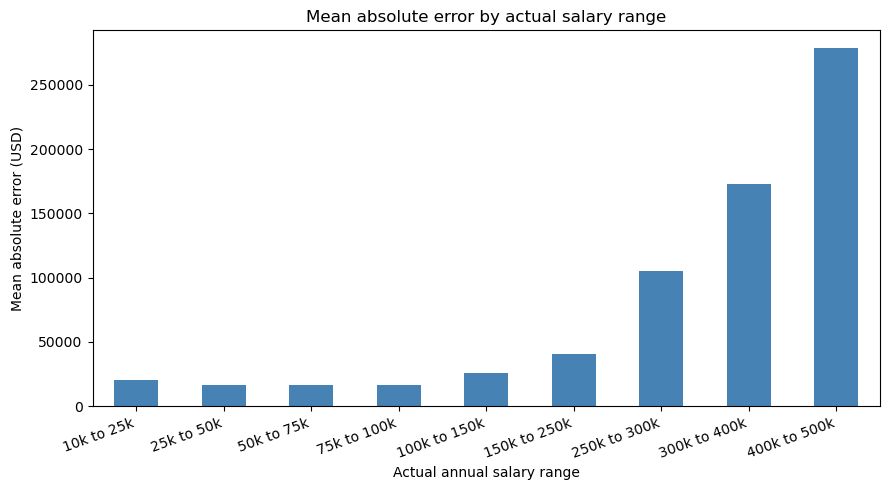

In [47]:
## Visualise the error across the salary range
error_by_range['MAE'].plot(kind='bar', figsize=(9, 5), color='steelblue')
plt.title('Mean absolute error by actual salary range')
plt.xlabel('Actual annual salary range')
plt.ylabel('Mean absolute error (USD)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [48]:
error_by_range[[
    'Test records',
    'MAE',
    'Average actual salary',
    'MAE as percentage of average salary'
]].round(2)

,Test records,MAE,Average actual salary,MAE as percentage of average salary
Salary range,,,,
10k to 25k,323,20062.80,17092.25,117.38
25k to 50k,691,16722.07,38731.83,43.17
50k to 75k,914,16006.80,62512.91,25.61
75k to 100k,818,16572.23,86457.25,19.17
100k to 150k,852,25852.57,121276.81,21.32
150k to 250k,624,40538.44,183030.00,22.15
250k to 300k,88,104991.56,266490.03,39.40
300k to 400k,76,172942.10,334743.01,51.66
400k to 500k,27,278615.21,441134.70,63.16


Absolute errors usually become larger at higher salaries, so the table includes record
counts, median error and MAE as a percentage of average salary. The narrower high-salary bands
avoid treating the entire USD 250k–500k section as one equally populated group.

After running the notebook, use these values to describe where the final model is reliable. A large
difference between MAE and median error suggests that a small number of difficult records are
pulling the mean upward.

## 5.4 Which features drive the prediction

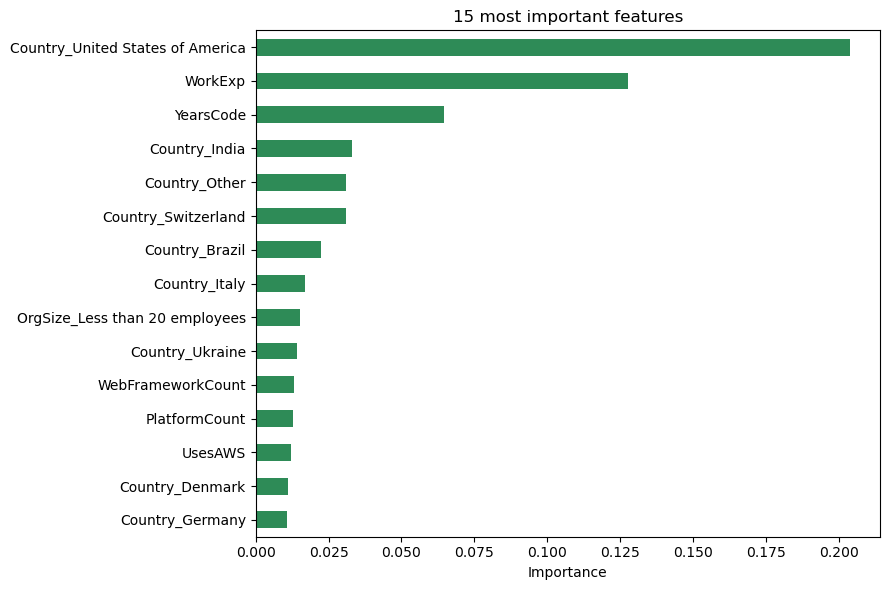

Features with zero importance: 8


Country_United States of America    0.2040
WorkExp                             0.1277
YearsCode                           0.0646
Country_India                       0.0332
Country_Other                       0.0310
Country_Switzerland                 0.0308
Country_Brazil                      0.0222
Country_Italy                       0.0169
OrgSize_Less than 20 employees      0.0152
Country_Ukraine                     0.0142
WebFrameworkCount                   0.0131
PlatformCount                       0.0129
UsesAWS                             0.0120
Country_Denmark                     0.0111
Country_Germany                     0.0108
dtype: float64

In [49]:
## Show the features the final model relies on most
all_feature_importance = pd.Series(
    best_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

feature_importance = all_feature_importance.head(15)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(9, 6),
    color='seagreen'
)
plt.title('15 most important features')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

print('Features with zero importance:', (all_feature_importance == 0).sum())
feature_importance.round(4)

Country and experience are among the most important features. This matches the earlier plots,
where salary differed strongly by country and generally increased with experience.


In [50]:
## Inspect predictions for salaries of USD 250k and above
high_salary_check = pd.DataFrame({
    'Actual salary': y_test.to_numpy(),
    'Predicted salary': y_pred_final
})

high_salary_check['Absolute error'] = np.abs(
    high_salary_check['Actual salary'] -
    high_salary_check['Predicted salary']
)

high_salary_check['Percentage error'] = (
    high_salary_check['Absolute error'] /
    high_salary_check['Actual salary'] * 100
)

high_salary_check = high_salary_check[
    high_salary_check['Actual salary'] >= 250_000
].copy()

print('Test records at or above USD 250k:', len(high_salary_check))
print(f"MAE:          USD {high_salary_check['Absolute error'].mean():,.2f}")
print(f"Median error: USD {high_salary_check['Absolute error'].median():,.2f}")
print(f"Highest salary: USD {high_salary_check['Actual salary'].max():,.2f}")

## Check how much of the total error comes from the five worst predictions
top_five_error_share = (
    high_salary_check['Absolute error'].nlargest(5).sum() /
    high_salary_check['Absolute error'].sum() * 100
)

print(f'Error contributed by the five worst predictions: {top_five_error_share:.2f}%')

Test records at or above USD 250k: 191
MAE:          USD 156,573.13
Median error: USD 131,960.27
Highest salary: USD 500,000.00
Error contributed by the five worst predictions: 5.90%


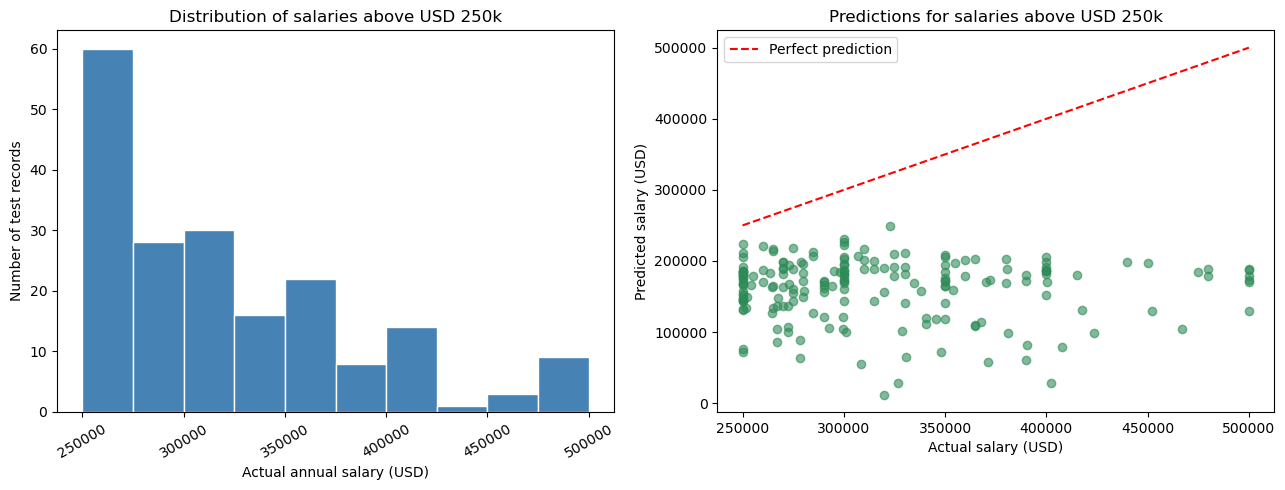

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

## Distribution of high salaries
ax[0].hist(
    high_salary_check['Actual salary'],
    bins=np.arange(250_000, 525_000, 25_000),
    color='steelblue',
    edgecolor='white'
)

ax[0].set_title('Distribution of salaries above USD 250k')
ax[0].set_xlabel('Actual annual salary (USD)')
ax[0].set_ylabel('Number of test records')
ax[0].tick_params(axis='x', rotation=30)

## Actual against predicted salary
ax[1].scatter(
    high_salary_check['Actual salary'],
    high_salary_check['Predicted salary'],
    alpha=0.6,
    color='seagreen'
)

ax[1].plot(
    [250_000, 500_000],
    [250_000, 500_000],
    color='red',
    linestyle='--',
    label='Perfect prediction'
)

ax[1].set_title('Predictions for salaries above USD 250k')
ax[1].set_xlabel('Actual salary (USD)')
ax[1].set_ylabel('Predicted salary (USD)')
ax[1].legend()

plt.tight_layout()
plt.show()

## 5.5 Conclusion

The final model is chosen from Gradient Boosting, tuned Gradient Boosting, Random Forest and tuned
Random Forest using the lowest training cross-validation MAE. The test MAE, RMSE and R² printed
above describe its performance on unseen records.

Compared with Salary 5.0, this version provides a continuous salary estimate instead of a broad
band and uses salary-specific regression metrics. It also keeps more location, role and industry
detail and includes summarised technology experience.

**After running all cells:** replace this sentence with your actual final model name and metrics.
Comment briefly on the train-test gap, the USD 250k–500k results and whether the achieved error is
acceptable for a survey-based comparison tool.

The estimate remains less reliable for sparse countries and salary ranges and does not include
employer-specific information, negotiation, equity or local cost of living.

# 6. Saving the Model

In [52]:
## Save the final model and the preprocessing information required by the web app
import joblib

model_package = {
    'model': best_model,
    'model_name': best_model_name,
    'col_x': col_x,
    'col_x_numeric': col_x_numeric,
    'col_x_categorical': col_x_categorical,
    'col_encoded': x_train.columns.tolist(),
    'col_options': col_options,
    'numeric_medians': numeric_medians.to_dict(),
    'category_top_values': category_top_values,
    'tech_count_sources': tech_count_sources,
    'tech_flags': tech_flags,
    'tech_options': tech_options,
    'best_params': best_model.get_params(),
    'test_mae': final_test_mae,
    'test_rmse': final_test_rmse,
    'test_r2': final_test_r2,
    'salary_floor': SALARY_FLOOR,
    'salary_ceiling': SALARY_CEILING,
    'training_rows': len(x_train)
}

joblib.dump(model_package, 'best_model.pkl')

print('Saved best_model.pkl')

Saved best_model.pkl


## Conclusion

MSE tuning produced better results for large prediction errors, particularly for salaries above USD 250,000. This was expected because MSE squares each error and therefore gives much more importance to large mistakes.

However, salaries above USD 250,000 represented a relatively small and less well-represented part of the dataset. MSE tuning placed greater emphasis on these uncommon records but did not produce the lowest average error across the full salary range.

The MAE-tuned model was therefore selected because it achieved the lowest cross-validation MAE and performed better for the majority of respondents. This matches the purpose of the application, which is to provide a useful general salary estimate rather than optimise mainly for a small number of very high salaries.

The model remains less reliable for salaries above USD 250,000, so predictions in that range should be interpreted with greater caution.